<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src="attachment:image.png" alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---


## Tarea 04 – Aprendizaje automático

- **Fecha de Entrega:** 13 de noviembre de 2025, a las 23:59.
- **Fecha de publicación**: 30 de octubre de 2025.
- **Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 04 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

### 1.2 Pregunta de ciencia de datos

Esta tarea tendrá como objetivo crear un predictor que determine el éxito o fracaso de una expedición a distintas montañas del Himalayas según datos del montañista y de la expedición. Vamos a responder a la pregunta de qué tan bien pueden atributos como año, estación, montaña, edad del montañista, entre otros, predecir el éxito o fracaso de una expedición.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

[The Himalayan Database](https://www.himalayandatabase.com/) consiste en una colección de registros de expediciones en la cordillera del Himalaya. Esta contiene información detallada de las cimas más altas del mundo, junto con miles de expediciones realizadas desde 1905 hasta 2024 e información de cada uno de los/las montañistas que han participado en ellas. (El dataset que utilizaremos fue extraído desde: https://mavenanalytics.io/data-playground/himalayan-expeditions)

Descargue el archivo `Himalayan+Expeditions.zip` disponible en el repositorio del curso. Como puede ver, esta información está separada en varios archivos `.csv`. Deberá utilizar las herramientas aprendidas durante el curso para juntar esta información, procesarla y crear un predictor que determine el éxito de una subida.

**Recomendación**: Puede revisar el archivo `himalayan_data_dictionary.csv` para saber el significado de cada una de las columnas de la base de datos.

### 2.1 Librerías

Para esta tarea puede utilizar cualquiera de las librerías previamente utilizadas en el curso. Puede agregar otras si lo estima conveniente para el desarrollo de la Tarea.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

## 3. Carga y limpieza (1 punto)

### 3.1 DataFrame unificado (0.2 pts)

Inspeccione los atributos de cada dataset y extraiga la siguiente información de ellos:

1. Información de las montañas:
    * ID de la cima (`peakid`)
    * Nombre común de la montaña (`pkname`)
    * Altura (m) (`heightm`)
    * Cantidad de expediciones exitosas (`success_exp`)
    * Cantidad de expediciones fallidas (`failed_exp`)

2. Información de las expediciones:
    * ID de la expedición (`expid`)
    * Año (`year`)
    * Estación del año (`season`)

3. Información de los montañistas:
    * ID del miembro (`memid`)
    * Sexo (`sex`)
    * Año de nacimiento (`yob`)
    * Nacionalidad (`citizen`)
    * Completó la expedición exitosamente (`msuccess`)

Genere un único DataFrame con todos estos atributos, donde cada fila represente el ascenso de un/a montañista en una expedición. (Ojo que esto no necesariamente significa que cada fila será una persona diferente: si una persona escaló dos cumbres distintas en dos expediciones, esta debería aparecer en su DataFrame como dos filas separadas.)


In [6]:
montañas_exp = pd.read_csv("data/peaks_with_exp.csv", dtype=str)
expediciones = pd.read_csv("data/exped.csv", dtype=str)
miembros = pd.read_csv("data/members.csv", dtype=str)

In [7]:
datos_montanas = montañas_exp[["peakid", "pkname", "heightm", "success_exp", "failed_exp"]]

datos_expediciones = expediciones[["expid", "peakid", "year", "season"]]

datos_montanistas = (miembros[["expid", "membid", "sex", "yob", "citizen", "msuccess"]])

ascensos = (
    datos_montanistas
      .merge(datos_expediciones, on="expid")
      .merge(datos_montanas, on="peakid")
      [["peakid", "pkname", "heightm", "success_exp", "failed_exp",
        "expid", "year", "season",
        "membid", "sex", "yob", "citizen", "msuccess"]]
)

ascensos


,peakid,pkname,heightm,success_exp,failed_exp,expid,year,season,membid,sex,yob,citizen,msuccess
0,AMAD,Ama Dablam,6814,1123,453,AMAD01101,2001,Spring,2,M,1972,Australia,FALSE
1,AMAD,Ama Dablam,6814,1123,453,AMAD01101,2001,Spring,1,M,1968,Australia,FALSE
2,AMAD,Ama Dablam,6814,1123,453,AMAD01101,2001,Spring,3,M,1960,Australia,FALSE
3,AMAD,Ama Dablam,6814,1123,453,AMAD01101,2001,Spring,4,M,1966,Australia,FALSE
4,AMAD,Ama Dablam,6814,1123,453,AMAD01101,2001,Spring,5,F,1970,Australia,FALSE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89084,SURM,Surma-Sarovar North,6564,1,3,SURM74101,1974,Spring,2,M,1944,UK,FALSE
89085,SURM,Surma-Sarovar North,6564,1,3,SURM74101,1974,Spring,3,M,NaN,UK,FALSE
89086,SURM,Surma-Sarovar North,6564,1,3,SURM74101,1974,Spring,4,M,1948,UK,FALSE
89087,SURM,Surma-Sarovar North,6564,1,3,SURM74101,1974,Spring,5,M,NaN,UK,FALSE


### 3.2 Limpieza y transformación (0.2 pts)

Inspeccione y procese su DataFrame para generar uno nuevo llamado `clean_df`. En esta sección usted debe decidir si es necesario:

* Limpiar valores nulos, duplicados o inválidos.
* Imputar valores.
* Transformar tipos de columnas.

Justifique su procesamiento.

In [8]:
clean_df = ascensos.copy()
nulos = clean_df.isna().sum()
duplicados = clean_df.duplicated().sum()
print("nulos por columna:\n", nulos)
print("numero de filas duplicadas:", duplicados)

clean_df.dropna(inplace=True)

nulos por columna:
 peakid            0
pkname            0
heightm           0
success_exp       0
failed_exp        0
expid             0
year              0
season            0
membid            0
sex               0
yob            5424
citizen           7
msuccess          0
dtype: int64
numero de filas duplicadas: 0


* ### **Primero miro el conteo de elementos nulos y que significan, como veo que tengo 5400 elementos nulos en la comuna de año de nacimiento, podria tratar de imputarlo, pero como es información que de por si no disponia para el calculo, y es un porcentaje minimo alrededor del 6%, creo que es mejor eliminarlos**

    ### **Con la misma logica, aun a escala infinitamente menor, son solo 7 datos de ciudadania que me faltan por lo que los voy a borrar**

    ### **Duplicados no hay, por lo que solo quedaria borrar los datos no validos y acomodar los tipos de los datos**

In [9]:
clean_df["year"] = clean_df["year"].astype("Int64")
clean_df["yob"] = clean_df["yob"].astype("Int64")
clean_df["heightm"] = clean_df["heightm"].astype("Int64")
clean_df["success_exp"] = clean_df["success_exp"].astype("Int64")
clean_df["failed_exp"] = clean_df["failed_exp"].astype("Int64")
clean_df["sex"] = clean_df["sex"].astype("category")
clean_df["citizen"] = clean_df["citizen"].astype("category")
clean_df["season"] = clean_df["season"].astype("category")

# pasar true/false a boolean
clean_df["msuccess"] = (clean_df["msuccess"].map({"TRUE": True, "FALSE": False})).astype("boolean")
clean_df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 83665 entries, 0 to 89088
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   peakid       83665 non-null  object  
 1   pkname       83665 non-null  object  
 2   heightm      83665 non-null  Int64   
 3   success_exp  83665 non-null  Int64   
 4   failed_exp   83665 non-null  Int64   
 5   expid        83665 non-null  object  
 6   year         83665 non-null  Int64   
 7   season       83665 non-null  category
 8   membid       83665 non-null  object  
 9   sex          83665 non-null  category
 10  yob          83665 non-null  Int64   
 11  citizen      83665 non-null  category
 12  msuccess     83665 non-null  boolean 
dtypes: Int64(5), boolean(1), category(3), object(4)
memory usage: 7.3+ MB


### 3.2 Creación de nuevas columnas (0.6 pts)

Vamos a crear un par de columnas nuevas que nos ayudarán a hacer una análisis exploratorio del dataset.
Utilizando las columnas actuales, genere y agregue las siguientes columnas a su DataFrame:

* `age`: Edad del montañista a la fecha de la expedición.
* `peak_success_p`: Porcentaje de expediciones exitosas de la cima respectiva.

De ser necesario, aplique procesos de limpieza y transformación a estas columnas también (asegúrese de que todos los valores sean coherentes).

* ### **Posterior a una investigación rapida, los registros tanto de la persona mas joven como de la mas vieja en escalar o ser cosiderado un alpinista son entre 7 y 86 años respectivamente,por lo que todo fuera del rango de [0, 90] deberia ser considerado un ingreso nulo o no valido para analizar** 

In [10]:
clean_df["age"] = (clean_df["year"] - clean_df["yob"]).astype("Int64")

rango_valido = clean_df["age"].between(0, 90)

clean_df.loc[~rango_valido, "age"] = pd.NA

clean_df["peak_success_p"] = (
    clean_df["success_exp"] /
    (clean_df["success_exp"] + clean_df["failed_exp"]) * 100
).round(1)

clean_df = clean_df.dropna()
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83591 entries, 0 to 89088
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   peakid          83591 non-null  object  
 1   pkname          83591 non-null  object  
 2   heightm         83591 non-null  Int64   
 3   success_exp     83591 non-null  Int64   
 4   failed_exp      83591 non-null  Int64   
 5   expid           83591 non-null  object  
 6   year            83591 non-null  Int64   
 7   season          83591 non-null  category
 8   membid          83591 non-null  object  
 9   sex             83591 non-null  category
 10  yob             83591 non-null  Int64   
 11  citizen         83591 non-null  category
 12  msuccess        83591 non-null  boolean 
 13  age             83591 non-null  Int64   
 14  peak_success_p  83591 non-null  Float64 
dtypes: Float64(1), Int64(6), boolean(1), category(3), object(4)
memory usage: 8.7+ MB


## 4. EDA (2.5 puntos)

Con el dataset obtenido, responda las siguientes preguntas. Para cada una de ellas, realice al menos un gráfico que permita visualizar el comportamiento de su dataset.

a. **(0.5 pts)** ¿Cuántos ascensos exitosos y fallidos hay en su dataset? ¿A qué porcentaje del total corresponde cada categoría?

b. **(0.5 pts)** ¿Cómo se distribuyen las edades de los/las montañistas en la base de datos?

c. **(0.5 pts)** ¿Cómo se distribuye la cantidad de ascensos según estación del año? ¿Cuál es el porcentaje de éxito por estación? Muestre la cantidad de filas de ascensos exitosas y fallidas para cada estación.

d. **(0.5 pts)** ¿Cómo cambia la cantidad de ascensos en el tiempo? Muestre la cantidad de ascensos exitosos y fallidos por año.

e. **(0.5 pts)** ¿Existe una correlación entre el porcentaje de éxito de ascenso y la altura de una cumbre? Haga un scatterplot para todas las cumbres que hayan sido escaladas por al menos 10 expediciones en total (tanto fallidas como exitosas).

,ascensos,porcentaje
msuccess,,
Fallido,48331,57.8
Exitoso,35260,42.2


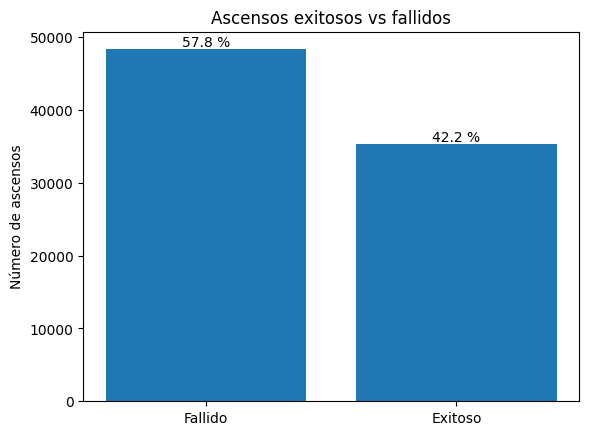

In [11]:
conteo = clean_df["msuccess"].value_counts().rename({True: "Exitoso", False: "Fallido"})
porcentaje = (conteo / conteo.sum() * 100).round(1)

display(conteo.to_frame("ascensos").assign(porcentaje=porcentaje))

fig, ax = plt.subplots()
ax.bar(conteo.index, conteo.values)
ax.set_ylabel("Número de ascensos")
ax.set_title("Ascensos exitosos vs fallidos")
for i, v in enumerate(conteo.values):
    ax.text(i, v, f"{porcentaje.iloc[i]} %", ha="center", va="bottom")
plt.show()


* ### **El porcentaje total de ascensos exitosos a los diferentes picos corresponde al 42,2% de los ascensos registrados, mientras que el porcentaje fallido corresponde al restante 57,8%**

count    83591.0
mean        38.3
std         10.6
min          7.0
25%         30.0
50%         37.0
75%         45.0
max         86.0
Name: age, dtype: Float64


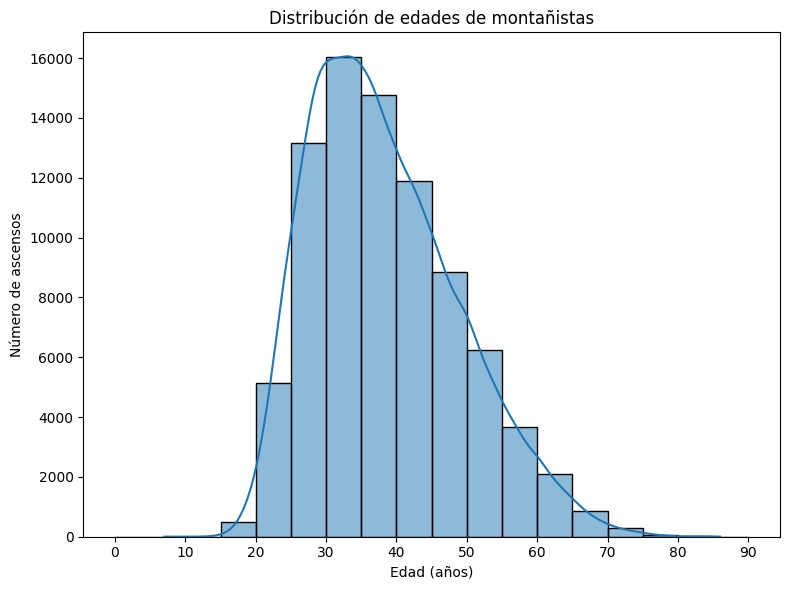

In [12]:
edad = clean_df["age"]
print(edad.describe().round(1))

plt.figure(figsize=(8,6))
sns.histplot(
    data=clean_df,
    x="age",
    bins=range(0, 91, 5),
    kde=True,
    edgecolor="black"
)
plt.xlabel("Edad (años)")
plt.ylabel("Número de ascensos")
plt.title("Distribución de edades de montañistas")
plt.xticks(range(0, 91, 10))
plt.tight_layout()
plt.show()

* ### **la edad promedio de los montañistas es 38 años y la mediana 37. El 50 % central se concentra entre 30 y 45 años (IQR), mientras que los extremos van de 7 a 86 años, aunque los casos por debajo de 20 o por encima de 70 son excepcionales. En síntesis, la mayor parte de las cumbres la logran personas en la treintena o cuarentena, cuando se combinan buena condición física y experiencia; la participación disminuye de forma marcada a partir de los 50 años.**

msuccess,Fallidos,Exitosos,% éxito
season,,,
Autumn,23924,15606,39.5
Spring,22304,18987,46.0
Summer,469,176,27.3
Winter,1634,491,23.1


<Figure size 800x600 with 0 Axes>

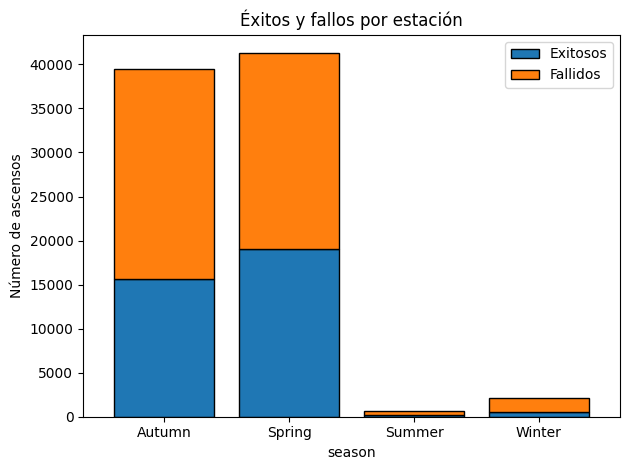

In [13]:
tabla = (
    clean_df
      .groupby("season", observed=True)["msuccess"]
      .value_counts()
      .unstack(fill_value=0)
      .rename(columns={True: "Exitosos", False: "Fallidos"})
      .sort_index()
)

tabla["% éxito"] = (tabla["Exitosos"] / tabla.sum(axis=1) * 100).round(1)
display(tabla)

# gráfico
plt.figure(figsize=(8,6))
tabla[["Exitosos", "Fallidos"]].plot(kind="bar", stacked=True, edgecolor="black", width=0.8)
plt.ylabel("Número de ascensos")
plt.title("Éxitos y fallos por estación")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

* ### **En primavera y otoño se concentran casi todos los intentos: alrededor de 41 000 cada una, con tasas de éxito del 46 % y 40 % respectivamente. En verano y, sobre todo, en invierno la actividad es mínima y el porcentaje de cumbre baja (27 % y 23 %). Esto nos indica que las ventanas de tiempo optimas para hacer cumbre de un pico son las temporadas intermedias que concentran mayor ventanas de exito en comparación**

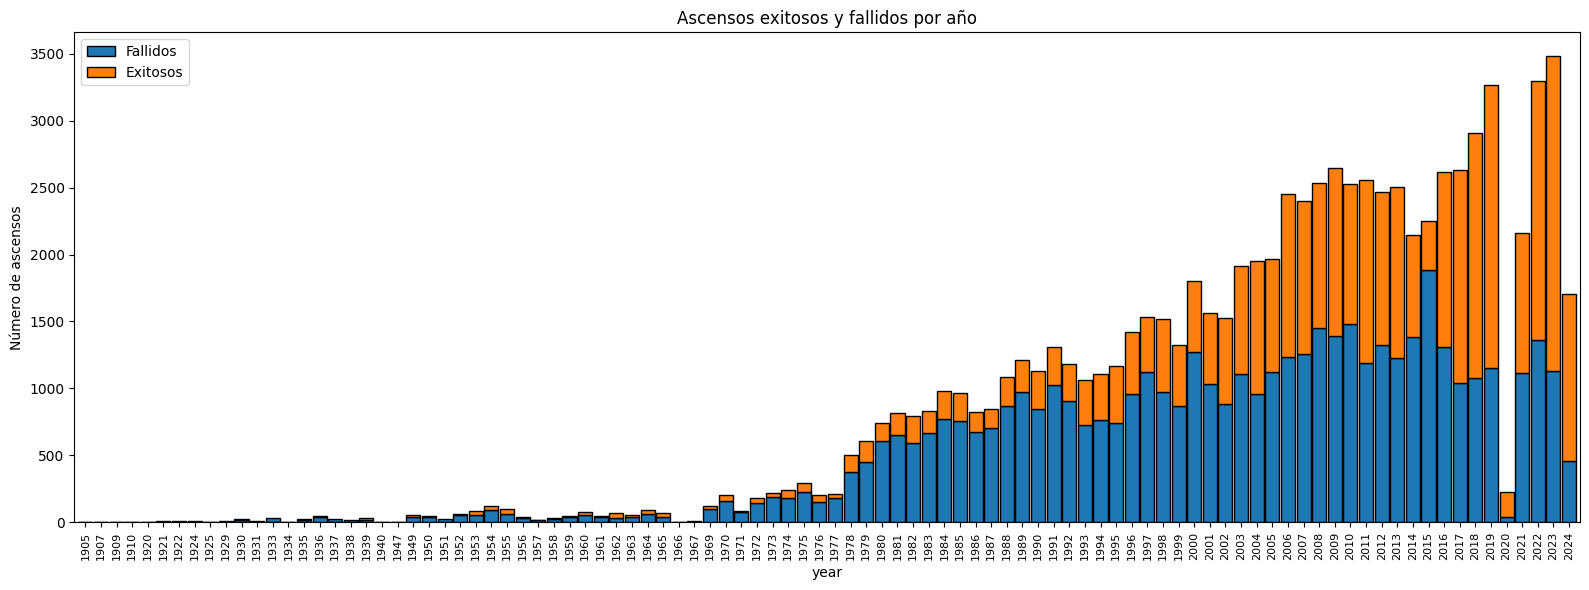

In [14]:
conteo_año = (
    clean_df
      .groupby(["year", "msuccess"], observed=True)
      .size()
      .unstack(fill_value=0)
      .rename(columns={True: "Exitosos", False: "Fallidos"})
      .sort_index()
)

fig, ax = plt.subplots(figsize=(16,6))
conteo_año.plot(kind="bar", stacked=True, width=0.9, ax=ax, edgecolor="black")
ax.set_ylabel("Número de ascensos")
ax.set_title("Ascensos exitosos y fallidos por año")
ax.set_xticklabels(conteo_año.index, rotation=90)
ax.tick_params(axis="x", labelsize=8)
ax.legend(title="")
plt.tight_layout()
plt.show()

* ### **d) Hasta los años 70 los intentos de cumbre eran contados y la mayoría terminaba sin éxito. A partir de esa década la actividad despega y, ya en los 90-2000, el número de ascensos crece casi en forma exponencial gracias a la profesionalización de las expediciones, el mejor equipamiento y las ventanas meteorológicas bien planificadas. Esa misma mejora se refleja en la proporción de éxitos, que pasa de ser marginal a superar la mitad de los intentos.**

    ### **El gráfico también deja ver descensos abruptos ligados a eventos externos: la caída tras el terremoto de Nepal en 2015 y el vacío de 2020-21 por la pandemia, despues de cada bajada la tendencia vuelve a crecer con pequeñas bajadas que se pueden atribuir a las criticas que estan recibiendo los gobiernos montañosos dado el tema de la sobreexplotacion de permisos para esta actividad.**

r = -0.332


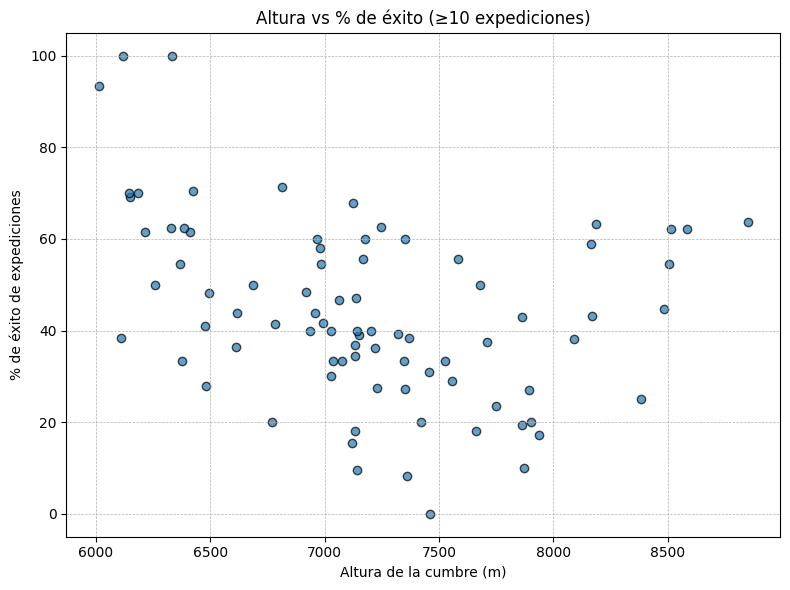

In [15]:
picos = (
    clean_df
      .groupby("peakid", observed=True)
      .agg(altura=("heightm", "first"),
           exito=("success_exp", "first"),
           fallo=("failed_exp", "first"))
)

picos["total"] = picos["exito"] + picos["fallo"]
picos = picos[picos["total"] >= 10]           # ≥10 expediciones
picos["%exito"] = picos["exito"] / picos["total"] * 100

# correlación
r = picos["altura"].corr(picos["%exito"])
print(f"r = {r:.3f}")

# scatter
plt.figure(figsize=(8,6))
plt.scatter(picos["altura"], picos["%exito"], alpha=0.7, edgecolors="k")
plt.xlabel("Altura de la cumbre (m)")
plt.ylabel("% de éxito de expediciones")
plt.title("Altura vs % de éxito (≥10 expediciones)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


* ### **El coeficiente de correlación r ≈ −0,33 indica una relación inversa moderada: en general, las cumbres más altas tienden a mostrar menores porcentajes de éxito, aunque la dispersión revela que la altura no explica por sí sola las probabilidades de alcanzar la cima—factores técnicos y meteorológicos también pesan bastante.**

## 5. Predictor (2.5 puntos)

Ahora veremos si la información que tenemos nos permite predecir el éxito de un ascenso por alguna persona en particular. Primero, defina su **X** (matriz de atributos) e **y** (etiqueta a predecir) de la siguiente manera:

* **X**: `age`, `sex`, `citizen`, `season`, `heightm`, `year`, `success_exp`, `failed_exp`
* **y**: `msuccess`

Luego, realice los pasos a continuación:

**5.1 Codificación y normalización (1 pto)**
* Codifique todas las columnas categóricas, de manera que su matriz **X** solo tenga valores numéricos.
* Divida sus datos en sets de entrenamiento y testeo. Use una división de 70-30.
* Normalice sus matrices de atributos. Justifique su método de normalización.

**5.2 Creación y entrenamiento de modelos (1 pto)**
* Cree y entrene los siguientes modelos:
    * Un clasificador KNN
    * Un árbol de decisión
    * Un clasificador de regresión logística
    * Un clasificador random forest **(Opcional)**

    Explique qué hiperparámetros utilizó para la creación de cada uno de ellos y qué valores le asignó.

* Finalmente, evalúe todos sus modelos con el set de testeo. Para cada uno, muestre
    * Accuracy
    * Precisión
    * Recall
    * Matriz de confusión

**5.3 Análisis de resultados (0.5 pts)**

Interprete, analice y comente sus resultados. 
* ¿Qué tendencias puede observar? ¿Se diferencian de alguna forma las predicciones entre un modelo y otro? 
* ¿Fue posible construir un predictor efectivo? Justique.



In [16]:
X = clean_df[["age", "sex", "citizen", "season",
              "heightm", "year", "success_exp", "failed_exp"]]
y = clean_df["msuccess"].astype(int)

num_cols = ["age", "heightm", "year", "success_exp", "failed_exp"]
cat_cols = ["sex", "citizen", "season"]

prepro = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_train_prep = prepro.fit_transform(X_train)
X_test_prep  = prepro.transform(X_test)

print("Entrenamiento:", X_train_prep.shape)
print("Testeo:", X_test_prep.shape)

Entrenamiento: (58513, 240)
Testeo: (25078, 240)


* ### **Se construyó X con las ocho variables indicadas y y con msuccess. Las columnas categóricas (sex, citizen, season) se transformaron mediante one-hot encoding para convertirlas en variables binarias; de este modo la matriz resultante contiene solo números y evita que el modelo asuma un orden inexistente entre categorías.**

    ### **Los datos se dividieron en un conjunto de entrenamiento y otro de testeo con proporción 70-30, usando stratify=y para mantener la misma distribución éxito/fallo en ambos sets y random_state=42 para reproducibilidad.**

    ### **Por último, las variables numéricas (age, heightm, year, success_exp, failed_exp) se normalizaron con StandardScaler, que centra cada columna en media 0 y la escala a desviación estándar 1. Este escalado es adecuado porque muchos algoritmos son sensibles a la magnitud de los predictores; además, aplicar el mismo preprocesamiento dentro de un ColumnTransformer garantiza que las mismas estadísticas aprendidas del set de entrenamiento se reutilicen en el set de prueba, evitando fugas de información.**

,accuracy,precision,recall,VP,FP,FN,VN
modelo,,,,,,,
knn,0.718319,0.679139,0.629703,6661,3147,3917,11353
arbol,0.734867,0.688044,0.679524,7188,3259,3390,11241
logistica,0.693596,0.672838,0.532520,5633,2739,4945,11761


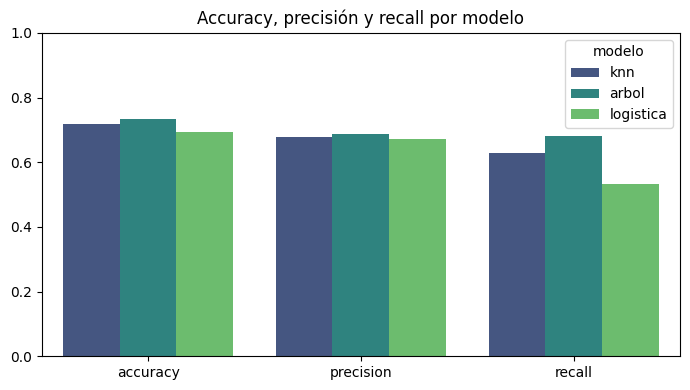

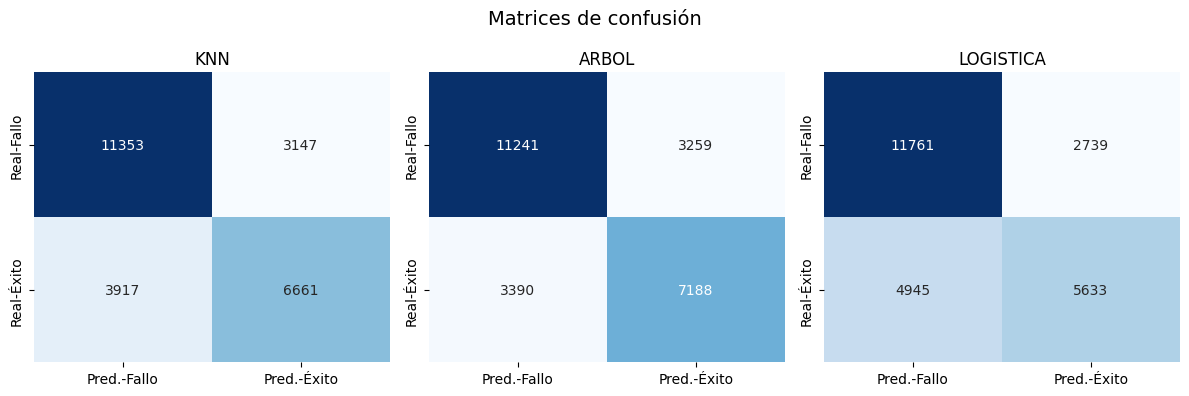

In [17]:
modelos = {
    "knn": KNeighborsClassifier(n_neighbors=7),
    "arbol": DecisionTreeClassifier(max_depth=10, random_state=42),
    "logistica": LogisticRegression(max_iter=1000, random_state=42)
}

resumen = []

for nombre, modelo in modelos.items():
    clf = Pipeline([("prep", prepro), ("model", modelo)])
    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)
    cm   = confusion_matrix(y_test, pred)

    resumen.append({
        "modelo": nombre,
        "accuracy":  accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall":    recall_score(y_test, pred),
        "VP": cm[1,1], "FP": cm[0,1],
        "FN": cm[1,0], "VN": cm[0,0]
    })

resumen_df = pd.DataFrame(resumen).set_index("modelo")
display(resumen_df)

metricas = ["accuracy", "precision", "recall"]
g = resumen_df[metricas].reset_index().melt(id_vars="modelo",
                                            var_name="métrica",
                                            value_name="valor")

plt.figure(figsize=(7,4))
sns.barplot(data=g, x="métrica", y="valor", hue="modelo", palette="viridis")
plt.ylim(0, 1)
plt.title("Accuracy, precisión y recall por modelo")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, (idx, fila) in zip(axes, resumen_df.reset_index().iterrows()):
    cm = [[fila["VN"], fila["FP"]],
          [fila["FN"], fila["VP"]]]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Pred.-Fallo", "Pred.-Éxito"],
                yticklabels=["Real-Fallo", "Real-Éxito"])
    ax.set_title(fila["modelo"].upper())

plt.suptitle("Matrices de confusión", fontsize=14)
plt.tight_layout()
plt.show()

## **Con KNN se fijó k = 7 porque, con 240 atributos tras el one-hot, un k muy bajo introduce ruido y uno muy alto diluye la vecindad; siete vecinos ofrece un equilibrio razonable y, al ser impar, evita empates.**
## **Para el árbol de decisión se limitó la profundidad a 10: con ~58 000 ejemplos esa cota captura interacciones sin memorizar el set; random_state = 42 solo garantiza reproducibilidad.**
## **En la regresión logística se mantuvo la configuración por defecto y solo se amplió max_iter = 1000 para asegurar convergencia con la matriz grande y dispersa.**
* ## **Resultados**

    # El árbol lidera con accuracy ≈ 0,735 y recall ≈ 0,680, seguido por KNN (0,718 / 0,630) y la logística (0,694 / 0,535).

    # Detecta 7 188 verdaderos éxitos, manteniendo una precisión similar a los otros (~0,68).


## **En conjunto, estos hiperparámetros equilibran sesgo y varianza: la profundidad moderada del árbol captura patrones no lineales sin sobreajustar, KNN se mantiene competitivo con una vecindad razonable, y la logística sirve como base lineal. Las métricas confirman que el árbol es el predictor más eficaz con la información disponible.**

